In [5]:
import numpy as np
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('../data/interim/olist_ml_processed_dataset.csv')

In [7]:
# Mapping dictionary for your classes
status_mapping = {
    'Very Early': 0,
    'Early': 1,
    'Late': 2,
    'Very Late': 3
}
df['delivery_label'] = df['delivery_status'].map(status_mapping)

In [8]:
X_raw = df.drop(columns=['delivery_delay_days', 'delivery_status', 'delivery_label']).values
y_raw = df['delivery_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)



# Features go to float32; labels go to long (integers) for CrossEntropyLoss
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# --- Step 4: Create DataLoaders ---
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 256  # Adjust this depending on your preferences

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True          # Shuffle training data to help generalization
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False          # No need to shuffle test/evaluation data
)

print(f"DataLoaders successfully created!")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

DataLoaders successfully created!
Train batches: 271 | Test batches: 68


In [9]:
class RegularizedDeepClassifier(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.2):
        super(RegularizedDeepClassifier, self).__init__()
        
        # Define the 5 Hidden Layers
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 16)
        self.fc5 = nn.Linear(16, 8)
        
        # Output layer mapping to 4 classes
        self.out = nn.Linear(8, 4)
        
        # Activations and Regularization
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # Apply Xavier Initialization immediately to all linear layers
        self._init_weights()
        
    def _init_weights(self):
        # Loop through all layers of the model
        for name, module in self.named_modules():
            if isinstance(module, nn.Linear):
                # Apply Xavier Uniform to weights
                nn.init.xavier_uniform_(module.weight)
                # Initialize biases to 0 (good practice)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)
        
    def forward(self, x):
        # Layer 1
        x = self.gelu(self.fc1(x))
        x = self.dropout(x)
        
        # Layer 2
        x = self.gelu(self.fc2(x))
        x = self.dropout(x)
        
        # Layer 3
        x = self.gelu(self.fc3(x))
        x = self.dropout(x)
        
        # Layer 4
        x = self.gelu(self.fc4(x))
        x = self.dropout(x)
        
        # Layer 5
        x = self.gelu(self.fc5(x))
        x = self.dropout(x)
        
        # Final Logits Output (No dropout on output layer)
        x = self.out(x)
        return x

# --- Initialization ---
input_features = X_train_tensor.shape[1]

# Instantiate your model (Dropout defaults to 0.2, adjust if needed)
model = RegularizedDeepClassifier(input_dim=input_features, dropout_rate=0.2)

# Loss and Optimizer remain setup for the updated architecture
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

RegularizedDeepClassifier(
  (fc1): Linear(in_features=7, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=16, bias=True)
  (fc5): Linear(in_features=16, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=4, bias=True)
  (gelu): GELU(approximate='none')
  (dropout): Dropout(p=0.2, inplace=False)
)


Epoch 01/100 | Train Loss: 0.5559 - Test Loss: 0.3456 | Train Acc: 86.36% - Test Acc: 88.77%
Epoch 02/100 | Train Loss: 0.3806 - Test Loss: 0.3352 | Train Acc: 88.57% - Test Acc: 88.80%
Epoch 03/100 | Train Loss: 0.3608 - Test Loss: 0.3323 | Train Acc: 88.74% - Test Acc: 88.82%
Epoch 04/100 | Train Loss: 0.3545 - Test Loss: 0.3312 | Train Acc: 88.77% - Test Acc: 88.80%
Epoch 05/100 | Train Loss: 0.3495 - Test Loss: 0.3293 | Train Acc: 88.78% - Test Acc: 88.76%
Epoch 06/100 | Train Loss: 0.3461 - Test Loss: 0.3273 | Train Acc: 88.79% - Test Acc: 88.76%
Epoch 07/100 | Train Loss: 0.3450 - Test Loss: 0.3266 | Train Acc: 88.75% - Test Acc: 88.76%
Epoch 08/100 | Train Loss: 0.3427 - Test Loss: 0.3271 | Train Acc: 88.75% - Test Acc: 88.77%
Epoch 09/100 | Train Loss: 0.3409 - Test Loss: 0.3262 | Train Acc: 88.80% - Test Acc: 88.74%
Epoch 10/100 | Train Loss: 0.3407 - Test Loss: 0.3262 | Train Acc: 88.80% - Test Acc: 88.78%
Epoch 11/100 | Train Loss: 0.3389 - Test Loss: 0.3252 | Train Acc: 88.

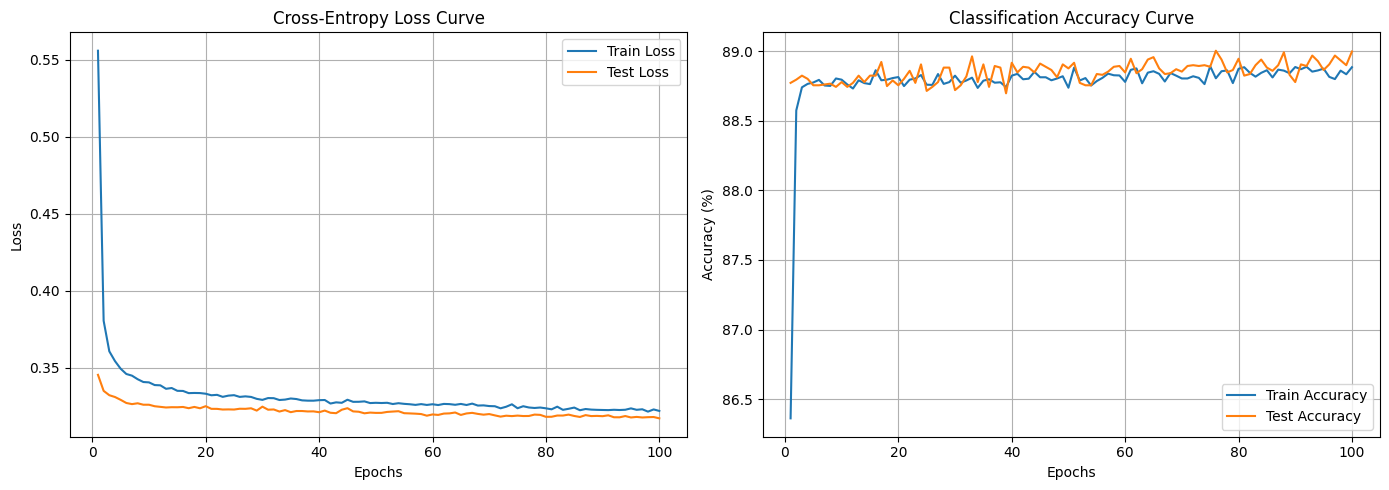

In [10]:
epochs = 100
history = {
    'train_loss': [], 'test_loss': [],
    'train_acc': [], 'test_acc': []
}

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    all_train_preds = []
    all_train_trues = []
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        
        # batch_y must be a 1D tensor of indices (shape: [batch_size])
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_X.size(0)
        
        # Get index of the highest logit prediction class
        _, preds = torch.max(outputs, 1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_trues.extend(batch_y.cpu().numpy())
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_acc = accuracy_score(all_train_trues, all_train_preds)
    
    # --- TESTING PHASE ---
    model.eval()
    running_test_loss = 0.0
    all_test_preds = []
    all_test_trues = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            running_test_loss += loss.item() * batch_X.size(0)
            
            _, preds = torch.max(outputs, 1)
            all_test_preds.extend(preds.cpu().numpy())
            all_test_trues.extend(batch_y.cpu().numpy())
            
    epoch_test_loss = running_test_loss / len(test_dataset)
    epoch_test_acc = accuracy_score(all_test_trues, all_test_preds)
    
    # --- Store Metrics ---
    history['train_loss'].append(epoch_train_loss)
    history['test_loss'].append(epoch_test_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_acc'].append(epoch_test_acc)
    
    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} - Test Loss: {epoch_test_loss:.4f} | "
          f"Train Acc: {epoch_train_acc*100:.2f}% - Test Acc: {epoch_test_acc*100:.2f}%")

# Print complete class breakdown analysis at completion
print("\nFinal Performance Breakdown:")
print(classification_report(all_test_trues, all_test_preds, target_names=list(status_mapping.keys())))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Cross-Entropy Loss Curve
axs[0].plot(range(1, epochs + 1), history['train_loss'], label='Train Loss')
axs[0].plot(range(1, epochs + 1), history['test_loss'], label='Test Loss')
axs[0].set_title('Cross-Entropy Loss Curve')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Accuracy Curve
axs[1].plot(range(1, epochs + 1), [acc * 100 for acc in history['train_acc']], label='Train Accuracy')
axs[1].plot(range(1, epochs + 1), [acc * 100 for acc in history['test_acc']], label='Test Accuracy')
axs[1].set_title('Classification Accuracy Curve')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()